In [1]:
!pip install pennylane qiskit qiskit-machine-learning qiskit-aer scikit-learn matplotlib pandas

imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

load & preprocess the dataset (Iris)

In [ ]:
data = load_iris()
X = data.data
y_true = data.target  

scaler = MinMaxScaler(feature_range=(0, np.pi))  
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(150, 4)

classical K-Means baseline

In [4]:
kmeans_classical = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_classical = kmeans_classical.fit_predict(X_scaled)

sil_classical = silhouette_score(X_scaled, labels_classical)
ari_classical = adjusted_rand_score(y_true, labels_classical)
print(f"Classical -> Silhouette: {sil_classical:.4f}, ARI: {ari_classical:.4f}")

Classical -> Silhouette: 0.5048, ARI: 0.7163


c:\Users\user\miniconda3\envs\myenvironment\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


PCA visualization of classical clusters

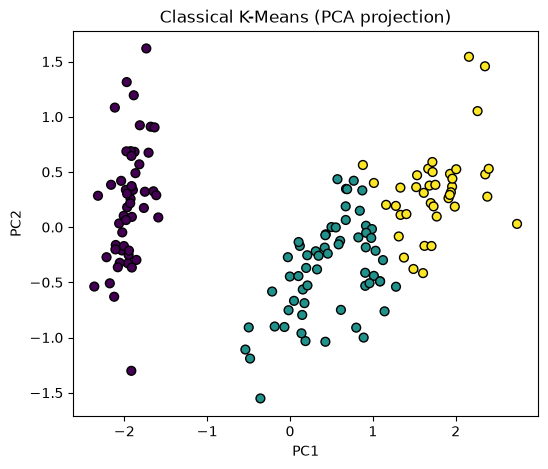

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_classical, cmap="viridis", s=40, edgecolor="k")
plt.title("Classical K-Means (PCA projection)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

PennyLane: define the quantum embedding circuit

In [6]:
import pennylane as qml

n_qubits = X_scaled.shape[1]  # 4
n_layers = 2
dev = qml.device("default.qubit", wires=n_qubits)

np.random.seed(42)
weights = np.random.uniform(0, 2*np.pi, size=(n_layers, n_qubits, 3))

@qml.qnode(dev)
def quantum_embedding_circuit(x, weights):
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation="Y")     # encode classical data
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))    # parameterised variational circuit
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]     # quantum feature vector

run every sample through the circuit

In [7]:
X_quantum_pl = np.array([quantum_embedding_circuit(x, weights) for x in X_scaled])
X_quantum_pl.shape

(150, 4)

K-Means on the PennyLane quantum features

In [8]:
kmeans_pl = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_pl = kmeans_pl.fit_predict(X_quantum_pl)

sil_pl = silhouette_score(X_quantum_pl, labels_pl)
ari_pl = adjusted_rand_score(y_true, labels_pl)
print(f"PennyLane quantum -> Silhouette: {sil_pl:.4f}, ARI: {ari_pl:.4f}")

c:\Users\user\miniconda3\envs\myenvironment\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


PennyLane quantum -> Silhouette: 0.4892, ARI: 0.6580


visualize PennyLane quantum clusters

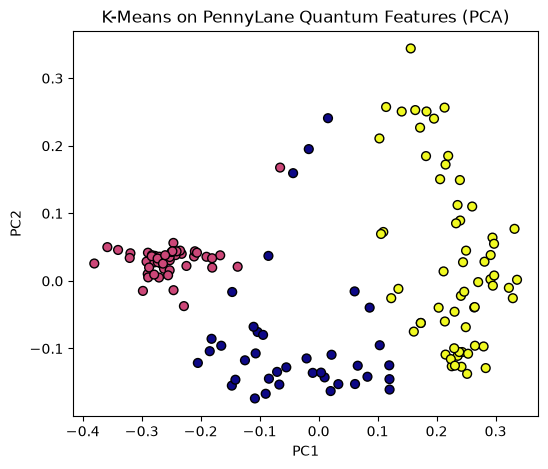

In [9]:
X_q_pca = PCA(n_components=2).fit_transform(X_quantum_pl)
plt.figure(figsize=(6,5))
plt.scatter(X_q_pca[:,0], X_q_pca[:,1], c=labels_pl, cmap="plasma", s=40, edgecolor="k")
plt.title("K-Means on PennyLane Quantum Features (PCA)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

now the Qiskit side, for the comparison. Define feature map + ansatz

In [10]:
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit.quantum_info import Statevector, SparsePauliOp

feature_map = zz_feature_map(feature_dimension=n_qubits, reps=1)
ansatz = real_amplitudes(num_qubits=n_qubits, reps=2)

np.random.seed(42)
ansatz_params = np.random.uniform(0, 2*np.pi, size=ansatz.num_parameters)

paulis = [SparsePauliOp("I"*i + "Z" + "I"*(n_qubits-i-1)) for i in range(n_qubits)]

extract quantum features via Qiskit statevectors

In [11]:
def get_qiskit_features(x):
    bound_fm = feature_map.assign_parameters(x)
    bound_ansatz = ansatz.assign_parameters(ansatz_params)
    circuit = bound_fm.compose(bound_ansatz)
    sv = Statevector(circuit)
    return [sv.expectation_value(p).real for p in paulis]

X_quantum_qk = np.array([get_qiskit_features(x) for x in X_scaled])
X_quantum_qk.shape

(150, 4)

K-Means + visualize Qiskit quantum features

c:\Users\user\miniconda3\envs\myenvironment\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Qiskit quantum -> Silhouette: 0.2007, ARI: 0.1055


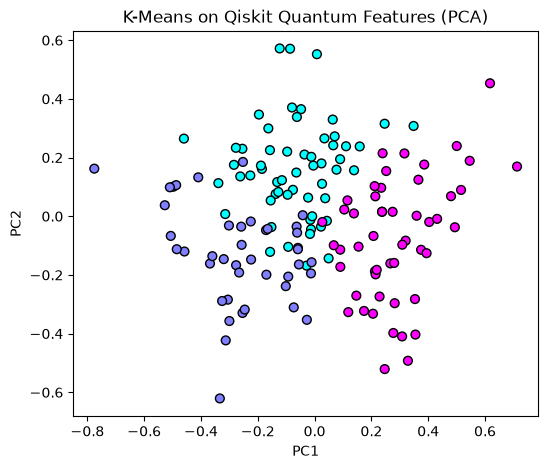

In [12]:
kmeans_qk = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_qk = kmeans_qk.fit_predict(X_quantum_qk)

sil_qk = silhouette_score(X_quantum_qk, labels_qk)
ari_qk = adjusted_rand_score(y_true, labels_qk)
print(f"Qiskit quantum -> Silhouette: {sil_qk:.4f}, ARI: {ari_qk:.4f}")

X_qk_pca = PCA(n_components=2).fit_transform(X_quantum_qk)
plt.figure(figsize=(6,5))
plt.scatter(X_qk_pca[:,0], X_qk_pca[:,1], c=labels_qk, cmap="cool", s=40, edgecolor="k")
plt.title("K-Means on Qiskit Quantum Features (PCA)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

final comparison table

In [13]:
import pandas as pd
results = pd.DataFrame({
    "Method": ["Classical K-Means", "PennyLane Quantum", "Qiskit Quantum"],
    "Silhouette": [sil_classical, sil_pl, sil_qk],
    "ARI": [ari_classical, ari_pl, ari_qk]
})
results

,Method,Silhouette,ARI
0,Classical K-Means,0.504769,0.716342
1,PennyLane Quantum,0.489219,0.657981
2,Qiskit Quantum,0.200724,0.105463
